Import libraries

In [1]:
import numpy as np
import xarray as xr
import cf_xarray
from xgcm import Grid, generate_grid_ds
import gsw_xarray as gsw

import numpy as np
import xarray as xr
import cf_xarray
import neutralocean
import neutralocean.grid.rectilinear
import neutralocean.ntp

from xgcm import Grid
import gsw_xarray as gsw

import matplotlib.pyplot as plt

import xarray as xr
import cf_xarray
import numpy as np
import jax
from jax import numpy as jnp
import optax
import matplotlib.pyplot as plt

## At first, we process dataset to add, SA, CT, etc

Open WOA23 dataset

In [2]:
ds = xr.open_mfdataset(
    "../data/woa23*.nc", decode_times=False
).squeeze("time", drop=True)[["t_an","s_an"]]
# We only keep the objectively analyzed mean fields
ds = ds.assign_coords({"lon":ds.lon%360}).sortby("lon")
ds.lon.attrs["standard_name"] = "longitude"

In [3]:
ds["p"] = gsw.p_from_z(z=-ds["depth"], lat=ds.lat)

In [4]:
# add CT and SA
ds["SA"] = ds.gsw.SA_from_SP()

In [5]:
ds["CT"] = ds.gsw.CT_from_t()

### Create xgcm.Grid

For this, we need to create some new dimensions

1. Create new dims: lon/lat/depth to x_c, y_c, z_c
1. Create new x_f, y_f, z_f dimensions that correspond to cell faces and add proper attributes
2. Add metrics
3. Create final grid

In [6]:
ds = generate_grid_ds(
    ds,
    {"X":ds.cf["longitude"].name, "Y":ds.cf["latitude"].name, "Z":ds.cf["depth"].name},
    position={'X':('center','right'),'Y':('center','right'),'Z':('center','right')}
)

In [7]:
for xyz, lld in zip(["x","y","z"],["longitude","latitude","depth"]):
    ds[f"{xyz}_c"] = (ds.cf[lld].name, np.arange(ds.cf[lld].shape[0]))
    ds = ds.swap_dims({ds.cf[lld].name:f"{xyz}_c"})
    ds[f"{xyz}_f"] = (ds.cf[lld].name+"_right", np.arange(ds.cf[lld].shape[0]))
    ds = ds.swap_dims({ds.cf[lld].name+"_right":f"{xyz}_f"})
    ds[f"{xyz}_c"].attrs["axis"] = ds[ds.cf[lld].name].attrs.pop("axis")
    ds[f"{xyz}_f"].attrs["axis"] = ds[ds.cf[lld].name+"_right"].attrs.pop("axis")
    ds[f"{xyz}_f"].attrs["c_grid_axis_shift"] = ds[ds.cf[lld].name+"_right"].attrs.pop("c_grid_axis_shift")
    ds[ds.cf[lld].name+"_right"].attrs["standard_name"] = lld

In [8]:
grid = Grid(ds, periodic=["X"])
grid

<xgcm.Grid>
Y Axis (not periodic, boundary=None):
  * center   y_c --> right
  * right    y_f --> center
Z Axis (not periodic, boundary=None):
  * center   z_c --> right
  * right    z_f --> center
X Axis (periodic, boundary=None):
  * center   x_c --> right
  * right    x_f --> center

In [9]:
dlong = 1
dlonc = 1

dlatg =1
dlatc = 1

In [10]:
def dll_dist(dlon, dlat, lon, lat):
        """Converts lat/lon differentials into distances in meters

        PARAMETERS
        ----------
        dlon : xarray.DataArray longitude differentials
        dlat : xarray.DataArray latitude differentials
        lon  : xarray.DataArray longitude values
        lat  : xarray.DataArray latitude values

        RETURNS
        -------
        dx  : xarray.DataArray distance inferred from dlon
        dy  : xarray.DataArray distance inferred from dlat
        """

        distance_1deg_equator = 111000.0
        dx = dlon * np.cos(np.deg2rad(lat)) * distance_1deg_equator
        dy = ((lon * 0) + 1) * dlat * distance_1deg_equator
        return dx, dy

ds.coords['e1tu'], e2 = dll_dist(dlonc, dlatc, ds.lon, ds.lat)
# e1tu is at u and t points => function of y_c
ds.coords['e2'] = np.nanmean(e2)
ds.coords['e1vf'], e2 = dll_dist(dlonc, dlatc, ds.lon, ds.lat_right)
# e1vf is at v and f points => function of y_f

In [11]:
ds.coords["e3w"] = grid.diff(
    ds["depth"],
    "Z",
    boundary="fill",
    fill_value=2*ds["depth"].values[-1] - ds["depth"].values[-2]
)

/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


In [12]:
ds.coords["e3t"] = grid.diff(
    ds["depth_right"],
    "Z",
    boundary="fill",
    fill_value=-ds["depth_right"].values[0]
)

### We recreate the xgcm.Grid with the new dataset

In [13]:
grid = Grid(ds, periodic=["X"], metrics={"X":["e1tu","e1vf"], "Y":["e2"], "Z":["e3t","e3w"]})
grid

<xgcm.Grid>
Y Axis (not periodic, boundary=None):
  * center   y_c --> right
  * right    y_f --> center
Z Axis (not periodic, boundary=None):
  * center   z_c --> right
  * right    z_f --> center
X Axis (periodic, boundary=None):
  * center   x_c --> right
  * right    x_f --> center

In [14]:
# we transpose the dataset to get (x,y,z) order
ds = ds.transpose(
    "x_c", "x_f", "y_c", "y_f", "z_c", "z_f", ...
)

## Computing reference density gradient $\vec{A}$

The density gradient is defined as:

$$
\vec{A} = \vec{\nabla} \rho_l
$$

with $\rho_l$ the potential density referenced locally. We transform the expression into:

$$
\vec{A} = - \alpha \vec{\nabla} \Theta + \beta \vec{\nabla} S_A
$$

So we need to compute:

#### $\alpha$ and $\beta$ at U, V, W points

we interpolate the $\alpha$ and $\beta$ from T points

#### Derivatives of $\Theta$ and $S_A$ at U, V, W points

In [15]:
dCT_dz = -grid.derivative(ds.cf["sea_water_conservative_temperature"], "Z")
# minus sign as z increases downward
dCT_dx = grid.derivative(ds.cf["sea_water_conservative_temperature"], "X")
dCT_dy = grid.derivative(ds.cf["sea_water_conservative_temperature"], "Y")

/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-package

In [16]:
dSA_dz = -grid.derivative(ds.cf["sea_water_absolute_salinity"], "Z")
# minus sign as z increases downward
dSA_dx = grid.derivative(ds.cf["sea_water_absolute_salinity"], "X")
dSA_dy = grid.derivative(ds.cf["sea_water_absolute_salinity"], "Y")

/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-package

In [17]:
alpha = gsw.alpha(
    ds.cf["sea_water_absolute_salinity"]*0+35,
    ds.cf["sea_water_conservative_temperature"]*0+10,
    gsw.p_from_z(z=-ds.depth, lat=ds.lat)*0
)
beta = gsw.beta(
    ds.cf["sea_water_absolute_salinity"]*0+35,
    ds.cf["sea_water_conservative_temperature"]*0+10,
    gsw.p_from_z(z=-ds.depth, lat=ds.lat)*0
)

In [18]:
rho = ds.gsw.rho()*0+1

In [19]:
Ax = (
    -dCT_dx * grid.interp(alpha, "X")
) + (
    dSA_dx * grid.interp(beta, "X")*0
)
Ax = Ax * grid.interp(rho, "X")

Ay = (
    -dCT_dy * grid.interp(alpha, "Y")
) + (
    dSA_dy * grid.interp(beta, "Y")*0
)
Ay = Ay * grid.interp(rho, "Y")

Az = -(
    -dCT_dz * grid.interp(alpha, "Z")
) + (
    dSA_dz * grid.interp(beta, "Z")*0
)
Az = Az * grid.interp(rho, "Z")

/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-package

In [20]:
for v,n in zip([alpha, beta, Ax, Ay, Az], ["alpha", "beta", "Ax", "Ay", "Az"]):
    ds[n] = v
ds["alpha_y"] = grid.interp(alpha, "Y")        

/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


In [21]:
ds

<xarray.Dataset> Size: 476MB
Dimensions:      (x_c: 360, y_c: 180, z_c: 102, x_f: 360, y_f: 180, z_f: 102)
Coordinates: (12/17)
    lat          (y_c) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
    depth        (z_c) float32 408B 0.0 5.0 10.0 ... 5.3e+03 5.4e+03 5.5e+03
    lon          (x_c) float32 1kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
    lon_right    (x_f) float32 1kB 1.0 2.0 3.0 4.0 ... 357.0 358.0 359.0 360.0
    lat_right    (y_f) float32 720B -89.0 -88.0 -87.0 -86.0 ... 88.0 89.0 90.0
    depth_right  (z_f) float32 408B 2.5 7.5 12.5 ... 5.35e+03 5.45e+03 5.55e+03
    ...           ...
  * z_f          (z_f) int64 816B 0 1 2 3 4 5 6 7 ... 94 95 96 97 98 99 100 101
    e1tu         (y_c) float32 720B 968.6 2.906e+03 ... 2.906e+03 968.6
    e2           float32 4B 1.11e+05
    e1vf         (y_f) float32 720B 1.937e+03 3.874e+03 ... 1.937e+03 -0.004852
    e3w          (z_f) float32 408B 5.0 5.0 5.0 5.0 ... 100.0 100.0 100.0 100.0
    e3t          (z_c) float32 408B 5.0 5.0 5.0 5.0 ... 100.0 100.0 100.0 100.0
Data variables:
    t_an         (x_c, y_c, z_c) float32 26MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    s_an         (x_c, y_c, z_c) float32 26MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    p            (y_c, z_c) float64 147kB 0.0 5.054 ... 5.529e+03 5.632e+03
    SA           (x_c, y_c, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    CT           (x_c, y_c, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    alpha        (x_c, y_c, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    beta         (x_c, y_c, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    Ax           (x_f, y_c, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    Ay           (x_c, y_f, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    Az           (x_c, y_c, z_f) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    alpha_y      (x_c, y_f, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
Attributes: (12/45)
    Conventions:                     CF-1.6
    title:                           World Ocean Atlas 2023 : sea_water_pract...
    summary:                         Climatological mean salinity for the glo...
    references:                      Reagan, J.R., D. Seidov, Z. Wang, D. Duk...
    institution:                     NOAA National Centers for Environmental ...
    comment:                         Global Climatology as part of the World ...
    ...                              ...
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v1.0
    license:                         These data are openly available to the p...
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    metadata_link:                   https://www.ncei.noaa.gov/products/world...
    date_created:                    2024-01-28 
    date_modified:                   2024-01-28

## Optimization of the surface

In [22]:
# We remove Arctic Ocean for simplicity

ds[[i for i in ds if "y_c" in ds[i].dims]] = ds[[i for i in ds if "y_c" in ds[i].dims]].where(ds.lat<65)
ds[[i for i in ds if "y_f" in ds[i].dims]] = ds[[i for i in ds if "y_f" in ds[i].dims]].where(ds.lat_right<65)

In [23]:
# we transpose the dataset to get (x,y,z) order
ds = ds.transpose(
    "x_c", "x_f", "y_c", "y_f", "z_c", "z_f", ...
)

In [24]:
ds

<xarray.Dataset> Size: 476MB
Dimensions:      (x_c: 360, y_c: 180, z_c: 102, x_f: 360, y_f: 180, z_f: 102)
Coordinates: (12/17)
    lat          (y_c) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
    depth        (z_c) float32 408B 0.0 5.0 10.0 ... 5.3e+03 5.4e+03 5.5e+03
    lon          (x_c) float32 1kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
    lon_right    (x_f) float32 1kB 1.0 2.0 3.0 4.0 ... 357.0 358.0 359.0 360.0
    lat_right    (y_f) float32 720B -89.0 -88.0 -87.0 -86.0 ... 88.0 89.0 90.0
    depth_right  (z_f) float32 408B 2.5 7.5 12.5 ... 5.35e+03 5.45e+03 5.55e+03
    ...           ...
  * z_f          (z_f) int64 816B 0 1 2 3 4 5 6 7 ... 94 95 96 97 98 99 100 101
    e1tu         (y_c) float32 720B 968.6 2.906e+03 ... 2.906e+03 968.6
    e2           float32 4B 1.11e+05
    e1vf         (y_f) float32 720B 1.937e+03 3.874e+03 ... 1.937e+03 -0.004852
    e3w          (z_f) float32 408B 5.0 5.0 5.0 5.0 ... 100.0 100.0 100.0 100.0
    e3t          (z_c) float32 408B 5.0 5.0 5.0 5.0 ... 100.0 100.0 100.0 100.0
Data variables:
    t_an         (x_c, y_c, z_c) float32 26MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    s_an         (x_c, y_c, z_c) float32 26MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    p            (y_c, z_c) float64 147kB 0.0 5.054 10.11 15.16 ... nan nan nan
    SA           (x_c, y_c, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    CT           (x_c, y_c, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    alpha        (x_c, y_c, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    beta         (x_c, y_c, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    Ax           (x_f, y_c, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    Ay           (x_c, y_f, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    Az           (x_c, y_c, z_f) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
    alpha_y      (x_c, y_f, z_c) float64 53MB dask.array<chunksize=(180, 90, 51), meta=np.ndarray>
Attributes: (12/45)
    Conventions:                     CF-1.6
    title:                           World Ocean Atlas 2023 : sea_water_pract...
    summary:                         Climatological mean salinity for the glo...
    references:                      Reagan, J.R., D. Seidov, Z. Wang, D. Duk...
    institution:                     NOAA National Centers for Environmental ...
    comment:                         Global Climatology as part of the World ...
    ...                              ...
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v1.0
    license:                         These data are openly available to the p...
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    metadata_link:                   https://www.ncei.noaa.gov/products/world...
    date_created:                    2024-01-28 
    date_modified:                   2024-01-28

In [25]:
# save for later use
ds.to_netcdf("dataset.nc")
ds.close()

# Breakpoint for the loading of data

In [26]:
ds = xr.open_mfdataset("dataset.nc")

### Defining the cost function

$$
J[\gamma] = \frac{1}{2}\int_V (\vec{\nabla} \gamma - \vec{\mathbf{A}})^2 \, dV
$$

In [27]:
# convert arrays of grad_h_z and depth into jax arrays

Ax = jnp.asarray(ds.Ax)
Ay = jnp.asarray(ds.Ay)
Az = jnp.asarray(ds.Az)

depth_U = jnp.asarray(ds.depth.broadcast_like(ds.Ax))
depth_V = jnp.asarray(ds.depth.broadcast_like(ds.Ay))

e1u = jnp.asarray(ds.e1tu)
e2v = jnp.asarray(ds.e2)

In [28]:
def compute_gradient(gamma, axis, e):
    """
    gamma : 3D arrays, shape (x,y,z)
    axis : axis on which to compute gradient, 0 for x, 1 for y, 2 for z
    e : scale factor
    """
    return (jnp.roll(gamma, -1, axis) - gamma) / e

In [29]:
# We define masks so the A is not NaNs at the boundaries

umask = jnp.where(
    jnp.isfinite(
        compute_gradient((ds.SA*0+1).values, 0, 1.)
    ),
    1,
    0
)

vmask = jnp.where(
    jnp.isfinite(
        compute_gradient((ds.SA*0+1).values, 1, 1.)
    ),
    1,
    0
)

wmask = jnp.where(
    jnp.isfinite(
        compute_gradient((ds.SA*0+1).values, 2, 1.)
    ),
    1,
    0
)

In [30]:
def compute_neutral_slope_along_surface_x(surface):
    out = interp_1d_at_every_point(
        x=(jnp.roll(surface,-1,0) + surface)/2, # interpolated at U point
        xp=depth_U,
        fp=grad_h_z_U
    )
    return out

def compute_neutral_slope_along_surface_y(surface):
    out = interp_1d_at_every_point(
        x=(jnp.roll(surface,-1,1) + surface)/2, # interpolated at V point
        xp=depth_V,
        fp=grad_h_z_V
    )
    return out

In [31]:
e1u = jnp.asarray(e1u[None,:,None])
e2v = jnp.asarray(e2v)
e3w = jnp.asarray(ds.e3w.values[None,None,:])


$$
J[\gamma] = \frac{1}{2}\int_V (\vec{\nabla} \gamma - \vec{\mathbf{A}})^2 \, dV
$$

In [32]:
def floss(gamma):
    """Loss function"""
    grad_U = jnp.nan_to_num(
        compute_gradient(gamma, axis=0, e=e1u)
    )
    grad_V = jnp.nan_to_num(
        compute_gradient(gamma, axis=1, e=e2v)
    )
    grad_W = -jnp.nan_to_num(
        compute_gradient(gamma, axis=2, e=e3w)
    )
    return jnp.nansum(
        (grad_U - Ax)**2 * umask + (grad_V - Ay)**2 * vmask + (grad_W - Az)**2 * wmask
    ) # not weighted integral
    

In [33]:
kappa_bar = grid.average(ds.gsw.kappa(), ["X", "Y"])

/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


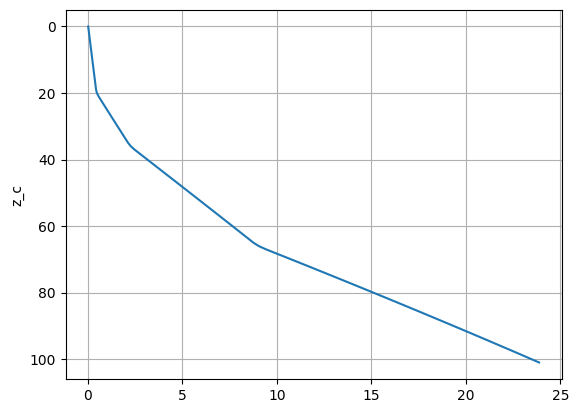

In [34]:
(grid.interp(grid.cumint(kappa_bar, "Z"), "Z", boundary="fill", fill_value=0)*1026*10000).plot(y="z_c", yincrease=False)
plt.grid()
# 1e4 to convert from Pa to dbar

In [35]:
# start from sigma2, or rho, or something else
# 1e4 to convert from Pa to dbar
gamma0 = ds.gsw.rho() - 1e4*grid.interp(grid.cumint(kappa_bar, "Z"), "Z", boundary="fill", fill_value=0)*1026

/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


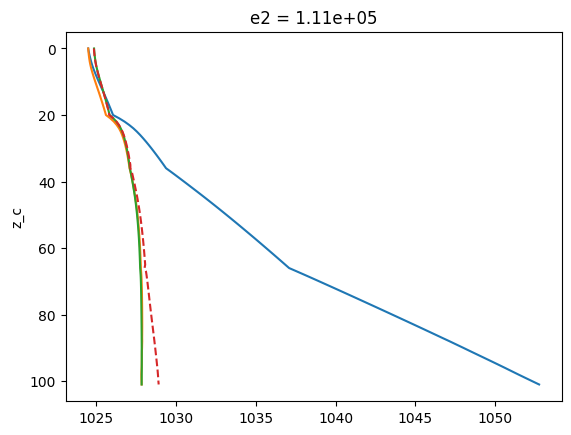

In [36]:
grid.average(ds.gsw.rho(), ["X","Y"]).plot(y="z_c", yincrease=False)
grid.average(ds.gsw.rho(p=0), ["X","Y"]).plot(y="z_c", yincrease=False)
ds.gsw.rho(p=0).mean(dim=("x_c", "y_c")).plot(y="z_c", yincrease=False)
gamma0.mean(dim=("x_c", "y_c")).plot(y="z_c", yincrease=False, linestyle="dashed")

In [37]:
ds.Ax.mean().compute(), ds.Ay.mean().compute(), ds.Az.mean().compute()

(<xarray.DataArray 'Ax' ()> Size: 8B
 array(1.54336417e-12)
 Coordinates:
     e2       float32 4B 1.11e+05,
 <xarray.DataArray 'Ay' ()> Size: 8B
 array(-1.00512954e-10)
 Coordinates:
     e2       float32 4B 1.11e+05,
 <xarray.DataArray 'Az' ()> Size: 8B
 array(1.84219179e-06)
 Coordinates:
     e2       float32 4B 1.11e+05)

In [38]:
def floss_xr(gamma):
    gamma_jax = jnp.asarray(gamma.transpose("x_c","y_c","z_c").values)
    return floss(gamma_jax)

In [39]:
tests_gammas = {
    "rho": ds.gsw.rho(),
    "sigma0": ds.gsw.sigma0(),
    "sigma2": ds.gsw.sigma2(),
    "rho - compress": ds.gsw.rho() - 1e4*grid.interp(grid.cumint(kappa_bar, "Z"), "Z", boundary="fill", fill_value=0)*1026,
    "constant": ds.CT*0,
    "pressure only": (ds.CT*0-ds.depth*ds.gsw.kappa()*1e4)*1026,
    "linear eos": (-ds.CT*ds.alpha + ds.SA*ds.beta-ds.depth*kappa_bar.mean()*1e4)*1026,
    "temperature": ds.CT*ds.alpha,
}

/home/romain/.cache/pypoetry/virtualenvs/neutral-density-BeRXjZM7-py3.10/lib/python3.10/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


In [40]:
for i in tests_gammas.keys():
    print(i, ", loss : ", floss_xr(tests_gammas[i]))

rho , loss :  510.75812
sigma0 , loss :  198.84491
sigma2 , loss :  232.35406
rho - compress , loss :  200.30768
constant , loss :  5.7111967e-05
pressure only , loss :  163.60747
linear eos , loss :  207.1397
temperature , loss :  3.792001e-12


In [41]:
# ok so it seems that the A vector already has a very small norm

In [42]:
# Test with a surface that has a constant slope
initial_gamma = jnp.asarray(tests_gammas["rho"].transpose("x_c","y_c","z_c").values)

In [43]:
floss(initial_gamma)

Array(510.75812, dtype=float32)

### Optimization

In [44]:
grad_loss = jax.grad(floss)

def train(params, learning_rate=0.01, num_steps=1000):
    """Train using gradient descent optimization"""
    # Define optimizer
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(params)
    
    losses = []
    
    for step in range(num_steps):
        # Compute loss and gradients
        loss = floss(params)
        #grads = jnp.nan_to_num(grad_loss(params))
        grads = grad_loss(params)
        
        losses.append(loss)
        
        # Apply updates
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        
        # Print progress every 100 steps
        if step % 100 == 0:
            print(f"Step {step}, Loss: {loss}")
            plt.imshow(params[:,:,10].T)
            plt.show()
    
    return params, losses

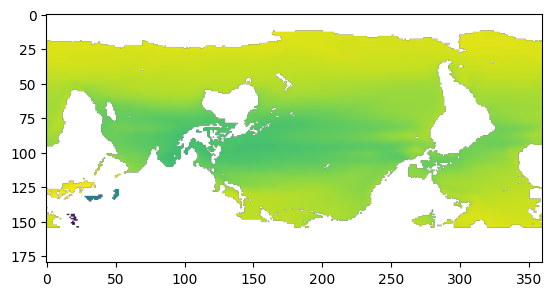

In [45]:
plt.imshow(initial_gamma[:,:,10].T)

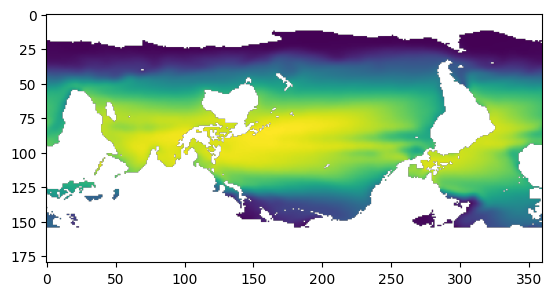

In [46]:
plt.imshow(ds.CT.values[:,:,10].T)

In [47]:
g = grad_loss(initial_gamma)

Step 0, Loss: 5.711196718038991e-05


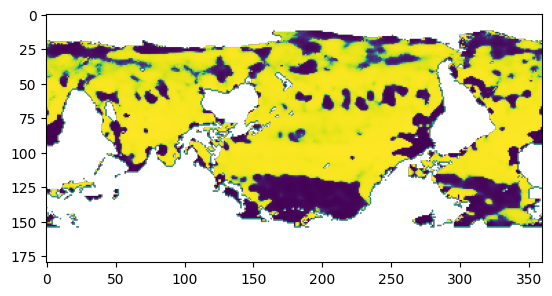

Step 100, Loss: 9.777272498467937e-05


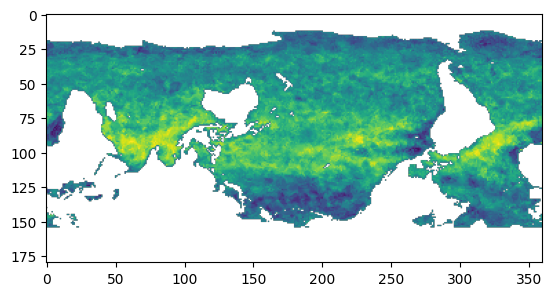

Step 200, Loss: 5.65906593692489e-05


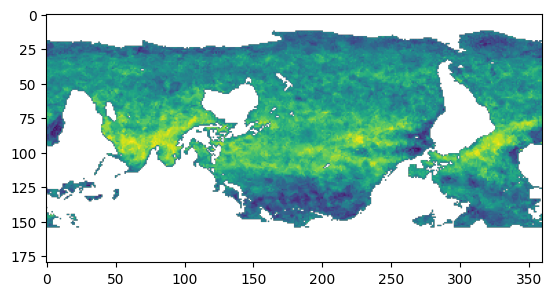

Step 300, Loss: 0.00021026539616286755


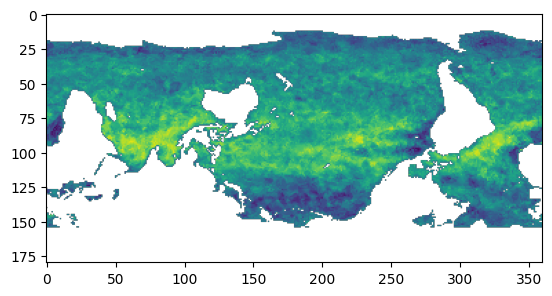

Step 400, Loss: 0.0005120157729834318


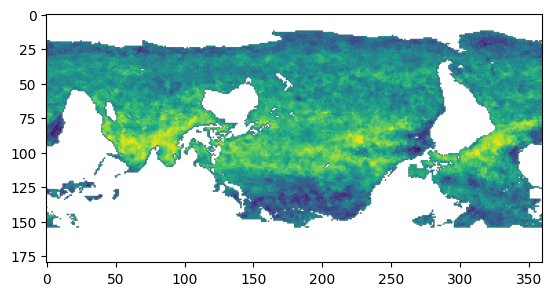

Step 500, Loss: 0.0007863963837735355


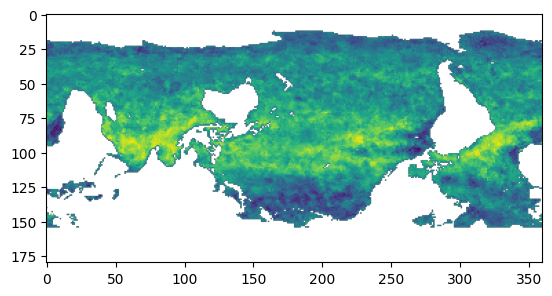

Step 600, Loss: 0.0013308948837220669


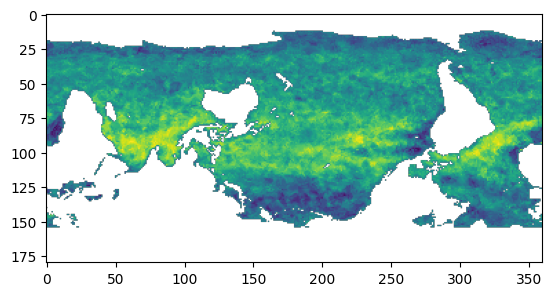

Step 700, Loss: 0.0018322147661820054


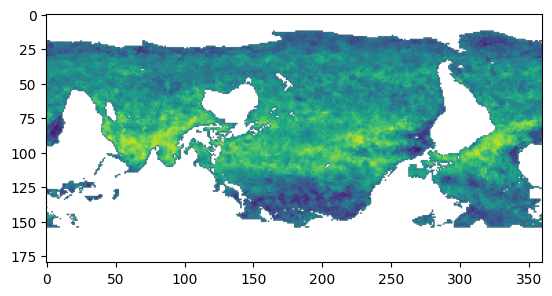

Step 800, Loss: 0.0025406416971236467


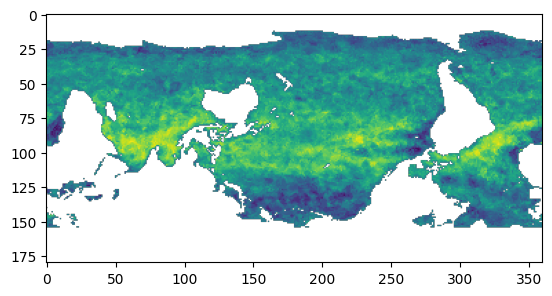

Step 900, Loss: 0.0029369117692112923


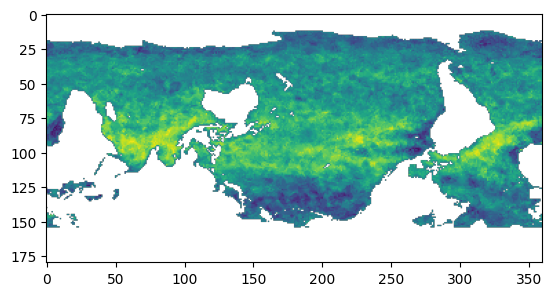

Step 1000, Loss: 0.0037433085963129997


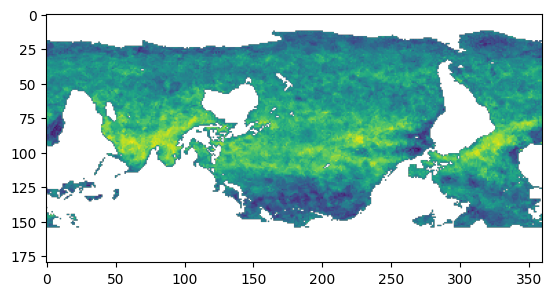

Step 1100, Loss: 0.00456168781965971


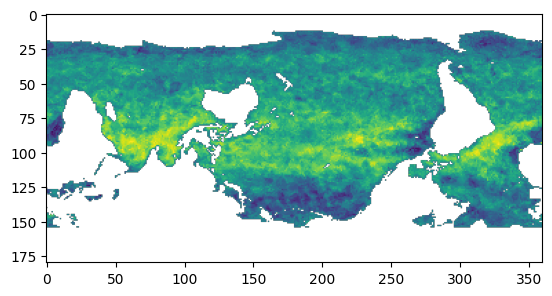

Step 1200, Loss: 0.005373994819819927


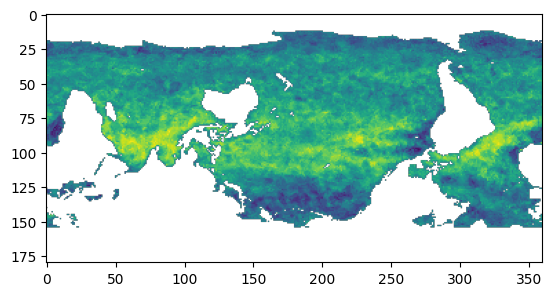

Step 1300, Loss: 0.005846980027854443


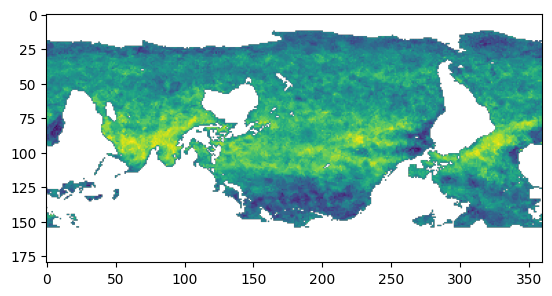

Step 1400, Loss: 0.006422225385904312


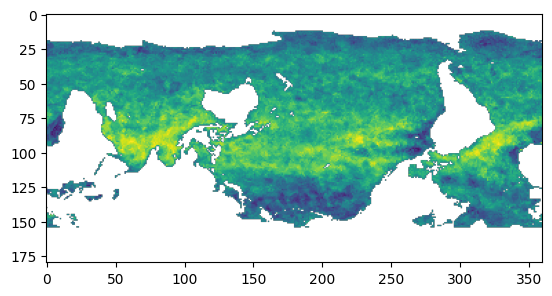

Step 1500, Loss: 0.007046476472169161


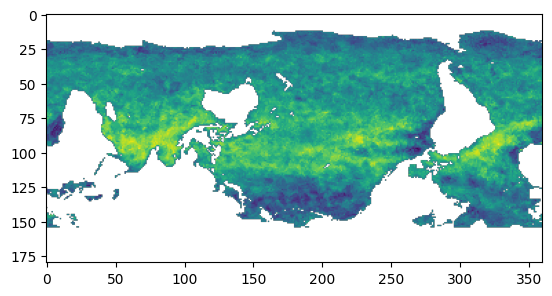

Step 1600, Loss: 0.007459308952093124


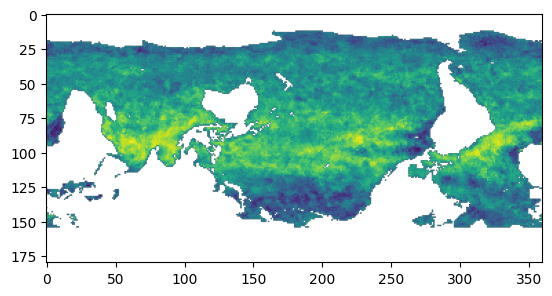

Step 1700, Loss: 0.007722089998424053


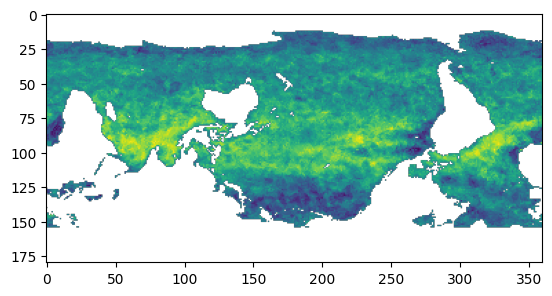

Step 1800, Loss: 0.007790905889123678


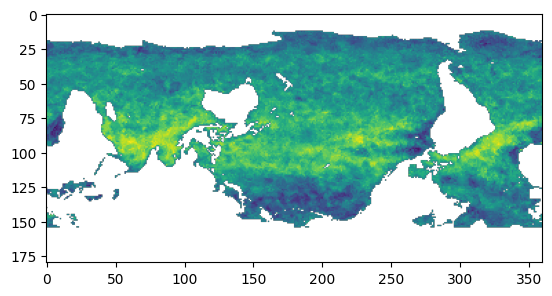

Step 1900, Loss: 0.007895132526755333


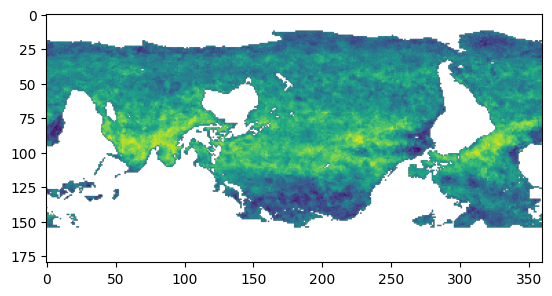

Step 2000, Loss: 0.00800435058772564


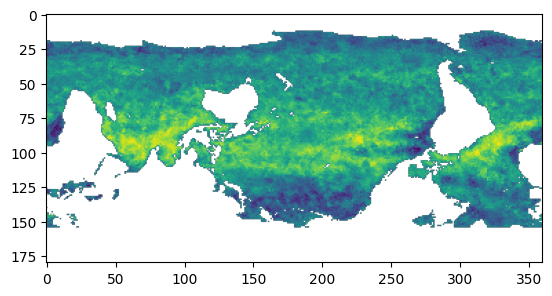

Step 2100, Loss: 0.008201329037547112


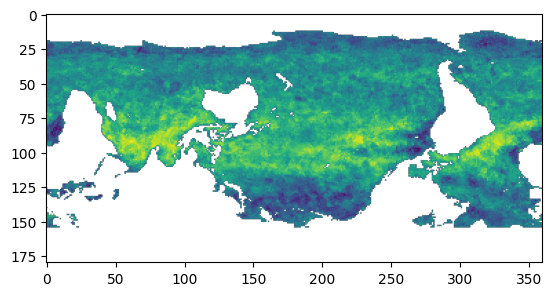

Step 2200, Loss: 0.008016765117645264


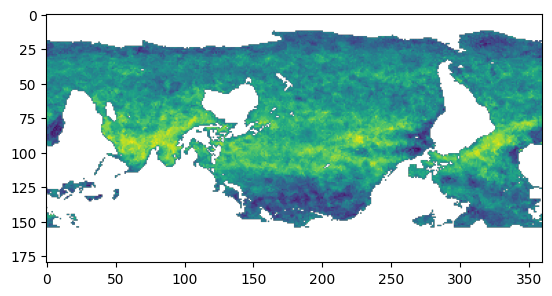

Step 2300, Loss: 0.007967723533511162


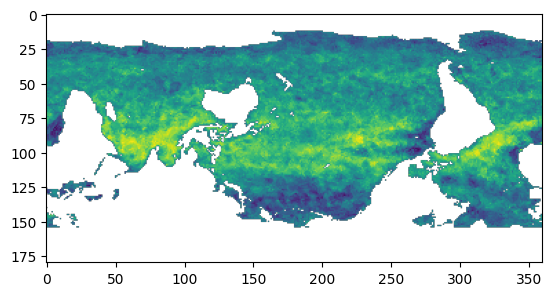

Step 2400, Loss: 0.00810920912772417


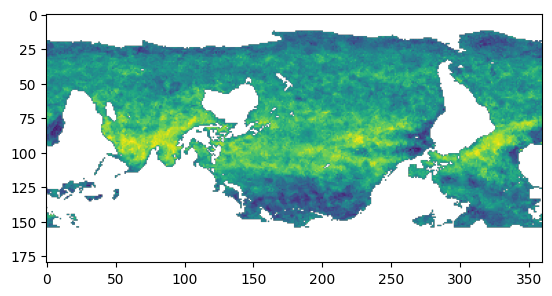

Step 2500, Loss: 0.008102654479444027


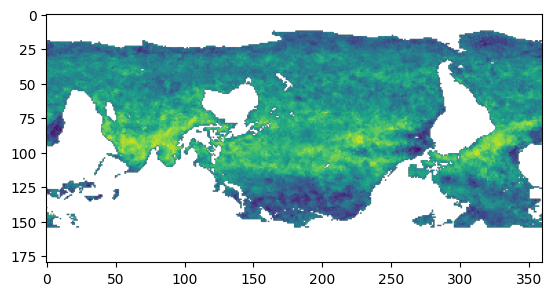

Step 2600, Loss: 0.008154100738465786


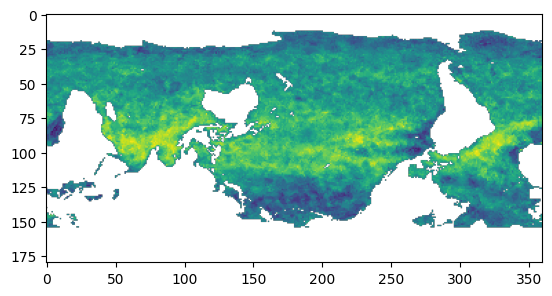

Step 2700, Loss: 0.008117937482893467


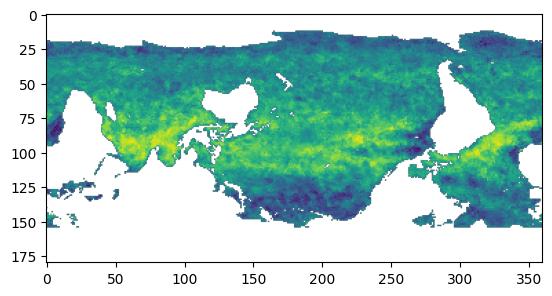

Step 2800, Loss: 0.008282653987407684


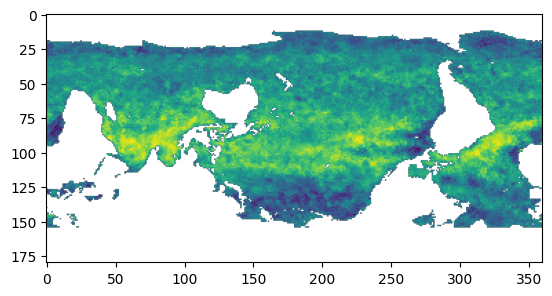

Step 2900, Loss: 0.00800181645900011


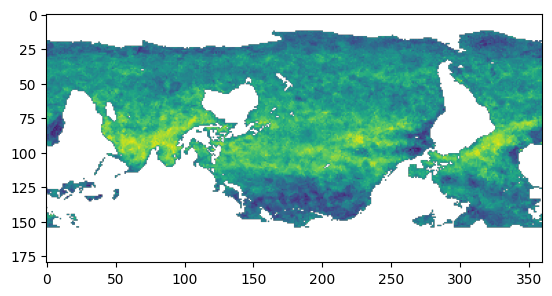

Optimization complete!
Initial loss: 510.75811767578125
Final loss: 0.008255467750132084


In [48]:
   
# Run optimization
optimal_gamma, loss_history = train(
    initial_gamma*0, 
    learning_rate=.01, 
    num_steps=3000
)

print("Optimization complete!")
print(f"Initial loss: {floss(initial_gamma)}")
print(f"Final loss: {floss(optimal_gamma)}")